# 0. 데이터 분석

Class
0    284315
1       492
Name: count, dtype: int64


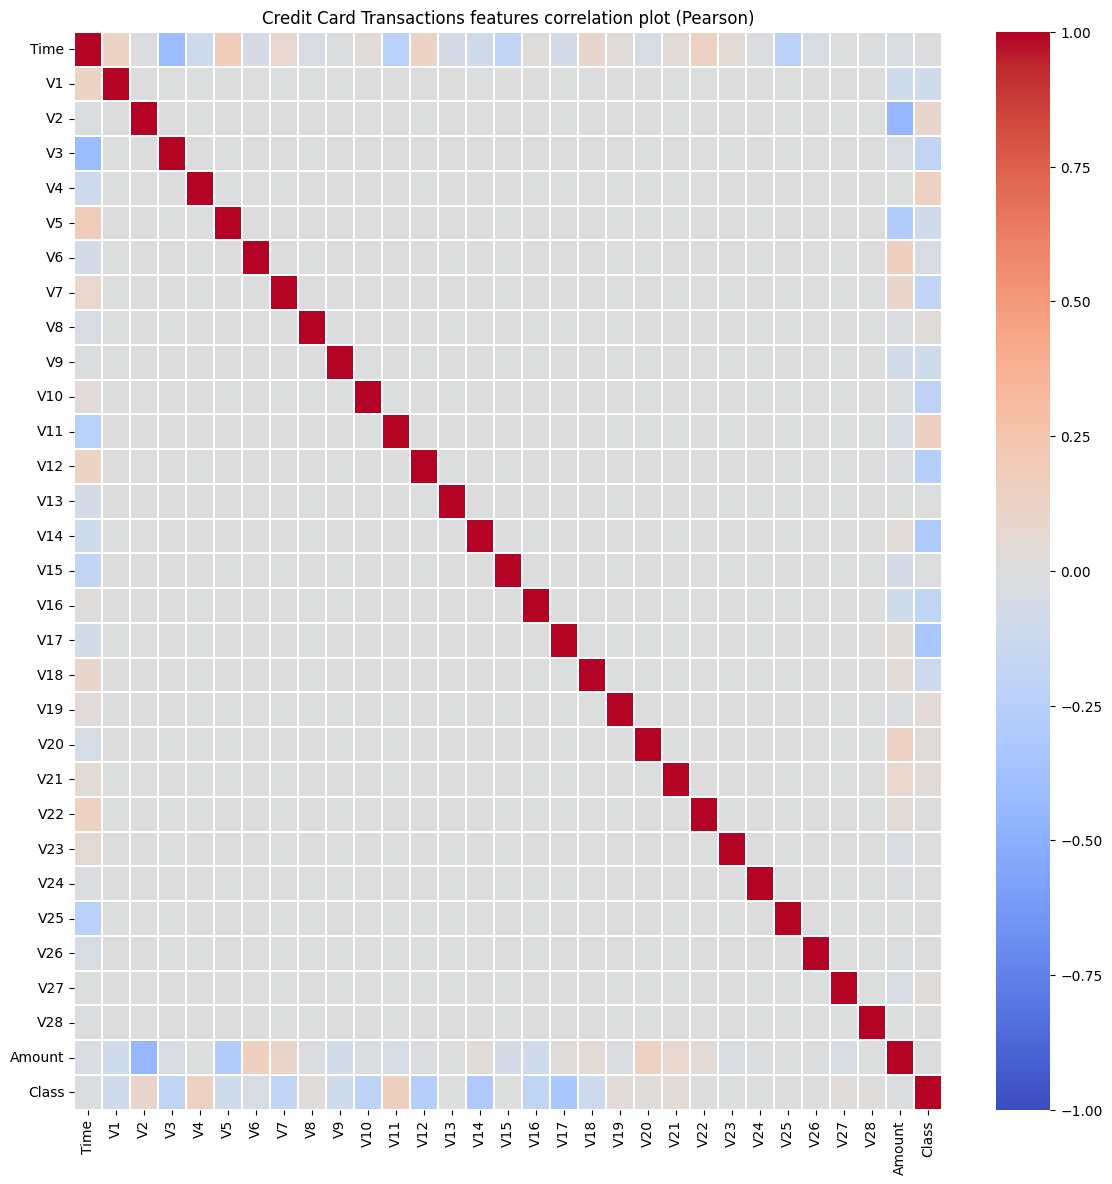

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

try:
    df = pd.read_csv('scaled.csv')
except FileNotFoundError:
    print("Error: 'creditcard.csv' 파일을 찾을 수 없습니다.")
    exit()
#--데이터 상관관계 분석 --
plt.figure(figsize=(14, 14))
plt.title('Credit Card Transactions features correlation plot (Pearson)')
corr = df.corr()
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, linewidths=.1, cmap="coolwarm", vmin=-1, vmax=1)
#--------------------------
#-- 데이터 불균형 분석------
print(df['Class'].value_counts())
#----------------------
plt.show()

- 데이터와 우리가 예측하려는 class간의 명확한 상관관계는 없음
- 데이터 유출의 가능성이 없기 때문에 해당 데이터를 이용하여, 모델을 다양화 하여 성능 분석에 초점을 맞춤

# 1. 데이터 전처리 (결측치 행 제거 및 train, test 셋 분리)

In [80]:
#lightGBM 방식으로 학습
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

try:
    df = pd.read_csv('scaled.csv')
except FileNotFoundError:
    print("Error: 'creditcard.csv' 파일을 찾을 수 없습니다.")
    exit()
# 1. (확인) 'Class' 열에 NaN이 있는지 확인
nan_count = df['Class'].isnull().sum()
if nan_count > 0:
    print(f"경고: 'Class' 열에 {nan_count}개의 NaN(결측치)이 있습니다. 이 행들을 제거합니다.")
    # 2. (해결) 'Class' 열에 NaN이 있는 행(row)을 제거
    df.dropna(subset=['Class'], inplace=True)

# 3. 이제 NaN이 없는 깨끗한 데이터로 X, y 분리
X_raw = df.drop('Class', axis=1)
y_raw = df['Class']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)
x_train_new, x_validation, y_train_new, y_validation = train_test_split(X_train_raw,y_train, test_size = 0.2, random_state = 42, stratify = y_train)



- train,test,validation을 각각 6 : 2 : 2 로 분리
- 한쪽 데이터에 사기 데이터가 몰리는 것을 방지하기 위해 random_state = 42 사용

# 2. 데이터 정규화 및 lightGBM 데이터셋 생성


In [81]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_new)
x_val_scaled = scaler.transform(x_validation)
x_test_scaled = scaler.transform(X_test_raw)

x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train_new.columns)
x_val_scaled   = pd.DataFrame(x_val_scaled,   columns=x_train_new.columns)
print("✅ 데이터 스케일링 완료 (StandardScaler)")
print(f"X_train_scaled shape: {x_train_scaled.shape}")
print(f"X_val_scaled shape: {x_val_scaled.shape}")
print(f"X_test_scaled shape: {x_test_scaled.shape}")

lgb_train = lgb.Dataset(x_train_scaled,y_train_new,feature_name = list(x_train_scaled.columns))
lgb_val = lgb.Dataset(x_val_scaled,y_validation,reference = lgb_train,feature_name = list(x_val_scaled.columns))

✅ 데이터 스케일링 완료 (StandardScaler)
X_train_scaled shape: (182276, 30)
X_val_scaled shape: (45569, 30)
X_test_scaled shape: (56962, 30)


# 3. lightGBM 파라미터 설정

In [49]:
params = {
    'objective' : 'binary',
    'metric' : 'binary_logloss',
    'boosting_type' : 'gbdt',
    'n_estimators' : 1000,
    'learning_rate' : 0.01,
    'num_leaves' : 31,
    'random_state' : 42,
    'is_unbalance' : True
}

# 4. 모델 학습

In [50]:
import lightgbm as lgb
evals_result = {}
gbm_baseline = lgb.train(
    params,
    lgb_train,
    num_boost_round = params['n_estimators'],
    valid_sets=[lgb_train,lgb_val],
    valid_names=['train','validation'],
    callbacks=[
        lgb.record_evaluation(evals_result),
        lgb.early_stopping(100, verbose=False)]
)
print(f"✅ 베이스라인 모델 학습 완료. 최적의 트리 개수: {gbm_baseline.best_iteration}")

[LightGBM] [Info] Number of positive: 315, number of negative: 181961
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.111306 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 182276, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001728 -> initscore=-6.358975
[LightGBM] [Info] Start training from score -6.358975
✅ 베이스라인 모델 학습 완료. 최적의 트리 개수: 713


# 4-1. 모델 학습 과정 시각화 (gemini 참조)

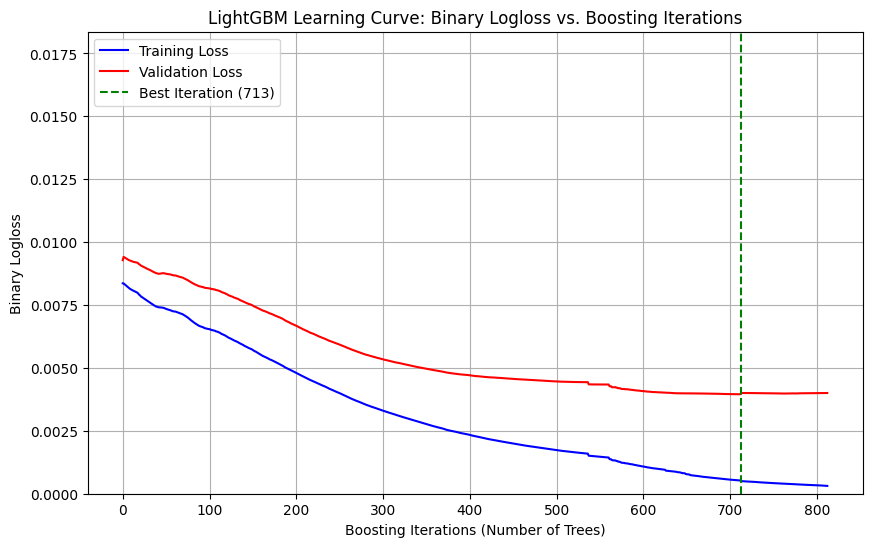

✅ 학습 곡선 그래프 시각화 완료.


In [51]:
import matplotlib.pyplot as plt
# --- 그래프 시각화 ---
metric_key = 'binary_logloss' # 사용자가 설정한 평가 지표 키

# 로그 손실 값 추출
train_loss = evals_result['train'][metric_key]
validation_loss = evals_result['validation'][metric_key]
iterations = range(len(train_loss))

plt.figure(figsize=(10, 6))

# 훈련 손실 곡선 (파란색)
plt.plot(iterations, train_loss, label='Training Loss', color='blue')

# 검증 손실 곡선 (빨간색)
plt.plot(iterations, validation_loss, label='Validation Loss', color='red')

# 조기 종료 지점 표시
best_iter = gbm_baseline.best_iteration
plt.axvline(best_iter, color='green', linestyle='--', label=f'Best Iteration ({best_iter})')

plt.title('LightGBM Learning Curve: Binary Logloss vs. Boosting Iterations')
plt.xlabel('Boosting Iterations (Number of Trees)')
plt.ylabel('Binary Logloss')
plt.legend()
plt.grid(True)
plt.ylim(0.0, max(train_loss) + 0.01) # y축 범위를 조정하여 낮은 값도 잘 보이도록 함
plt.show()

print("✅ 학습 곡선 그래프 시각화 완료.")

# 4-2. 특성 중요도 확인

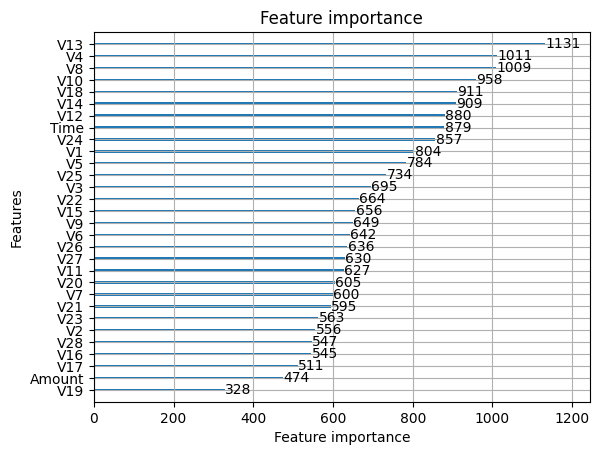

In [52]:
from lightgbm import plot_importance

plot_importance(gbm_baseline)
plt.show()

- baseline모델은 13번째 특성을 기준으로 분할하였을때, 손실값이 제일 크게 감소

# 5. 모델 훈련 성능 측정(훈련 데이터) - 훈련 성능 측정 부분 gemini 참조

In [53]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
# 확률 예측: 훈련 데이터에 대해 예측 수행
y_pred_proba_train = gbm_baseline.predict(
    x_train_scaled,
    num_iteration=gbm_baseline.best_iteration
)

# 분류 예측 (임계값 0.5 사용)
threshold = 0.5
y_pred_train = (y_pred_proba_train >= threshold).astype(int)

# 성능 지표 계산
roc_auc_train = roc_auc_score(y_train_new, y_pred_proba_train)
precision_train = precision_score(y_train_new, y_pred_train)
recall_train = recall_score(y_train_new, y_pred_train)

print("\n--- 📈 LightGBM 훈련 (Train) 세트 성능 ---")
print(f"  - ROC AUC: {roc_auc_train:.4f} (이 수치는 높을수록 좋음)")
print(f"  - 정밀도 (Precision): {precision_train:.4f}")
print(f"  - 재현율 (Recall): {recall_train:.4f}")
print("-----------------------------------------")


--- 📈 LightGBM 훈련 (Train) 세트 성능 ---
  - ROC AUC: 1.0000 (이 수치는 높을수록 좋음)
  - 정밀도 (Precision): 0.9488
  - 재현율 (Recall): 1.0000
-----------------------------------------


- 훈련 데이터에 대한 과대적합 발견

# 5-1. 검증 데이터에 대한 성능 측정

In [54]:
# --- 검증 (Validation) 세트 성능 측정 ---
print("\n--- 📊 검증 (Validation) 세트 성능 측정 ---")
# 확률 예측: 검증 데이터에 대해 예측 수행
y_pred_proba_val = gbm_baseline.predict(
    x_val_scaled,
    num_iteration=gbm_baseline.best_iteration # 최적의 반복 횟수 사용
)

# 분류 예측 (임계값 0.5 사용)
y_pred_val = (y_pred_proba_val >= threshold).astype(int)

# 성능 지표 계산
roc_auc_val = roc_auc_score(y_validation, y_pred_proba_val)
precision_val = precision_score(y_validation, y_pred_val)
recall_val = recall_score(y_validation, y_pred_val)

print("\n--- 📝 LightGBM 검증 (Validation) 세트 성능 ---")
print(f"  - ROC AUC: {roc_auc_val:.4f}")
print(f"  - 정밀도 (Precision): {precision_val:.4f}")
print(f"  - 재현율 (Recall): {recall_val:.4f}")
print("---------------------------------------------")


--- 📊 검증 (Validation) 세트 성능 측정 ---

--- 📝 LightGBM 검증 (Validation) 세트 성능 ---
  - ROC AUC: 0.9467
  - 정밀도 (Precision): 0.8378
  - 재현율 (Recall): 0.7848
---------------------------------------------


# 5-2. 테스트 데이터에 대한 성능 측정(일반화)

In [55]:
# --- 테스트 (Test) 세트 성능 측정 ---
print("\n--- 🏁 최종 테스트 (Test) 세트 성능 측정 시작 ---")

# 확률 예측: 테스트 데이터에 대해 예측 수행
# LightGBM의 최적의 트리 개수(best_iteration)를 사용하여 예측합니다.
y_pred_proba_test = gbm_baseline.predict(
    x_test_scaled,
    num_iteration=gbm_baseline.best_iteration
)

# 분류 예측 (임계값 0.5 사용)
threshold = 0.5
y_pred_test = (y_pred_proba_test >= threshold).astype(int)

# 성능 지표 계산
roc_auc_test = roc_auc_score(y_test, y_pred_proba_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)

# 결과 출력
print("\n--- 🥇 LightGBM 최종 테스트 (Test) 세트 성능 ---")
print(f"  - ROC AUC: {roc_auc_test:.4f} (일반화 성능의 주요 지표)")
print(f"  - 정밀도 (Precision): {precision_test:.4f}")
print(f"  - 재현율 (Recall): {recall_test:.4f}")
print("--------------------------------------------------")


--- 🏁 최종 테스트 (Test) 세트 성능 측정 시작 ---

--- 🥇 LightGBM 최종 테스트 (Test) 세트 성능 ---
  - ROC AUC: 0.9846 (일반화 성능의 주요 지표)
  - 정밀도 (Precision): 0.8100
  - 재현율 (Recall): 0.8265
--------------------------------------------------


- 정밀도 : 사기로 분류한 것 중 실제 사기의 비율
- 재현율 : 실제 사기인것들 중 사기로 분류한 비율

# 6. 과적합 방지를 위한 하이퍼 파라미터 조절

In [82]:
params = {
    'objective' : 'binary',
    'metric' : 'binary_logloss',
    'boosting_type' : 'gbdt',
    'n_estimators' : 1000,
    'learning_rate' : 0.01,
    'num_leaves' : 31,
    'random_state' : 42,
    'colsample_bytree': 0.7, # 과적합 방지 및 일반화 성능 향상을 위한 특성,행 샘플링
    'subsample' : 0.9,
    'subsample_freq' : 1, # 행 샘플링 적용시, 특성 샘플링만 적용 했을때보다 성능이 떨어짐
    'is_unbalance' : True
}

In [83]:
import lightgbm as lgb
evals_result = {}
gbm_baseline = lgb.train(
    params,
    lgb_train,
    num_boost_round = params['n_estimators'],
    valid_sets=[lgb_train,lgb_val],
    valid_names=['train','validation'],
    callbacks=[
        lgb.record_evaluation(evals_result),
        lgb.early_stopping(100, verbose=False)]
)
print(f"✅ 베이스라인 모델 학습 완료. 최적의 트리 개수: {gbm_baseline.best_iteration}")

[LightGBM] [Info] Number of positive: 315, number of negative: 181961
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.047717 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 182276, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001728 -> initscore=-6.358975
[LightGBM] [Info] Start training from score -6.358975
✅ 베이스라인 모델 학습 완료. 최적의 트리 개수: 867


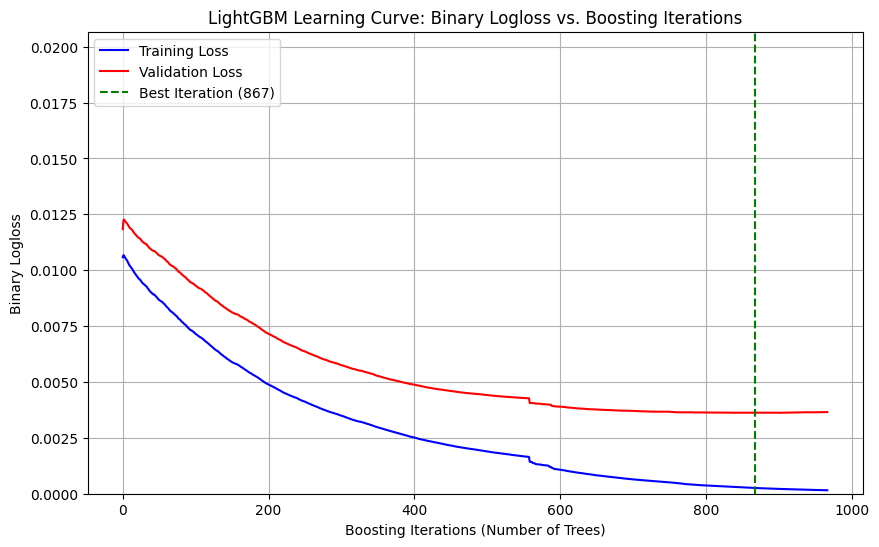

✅ 학습 곡선 그래프 시각화 완료.


In [84]:
import matplotlib.pyplot as plt
# --- 그래프 시각화 ---
metric_key = 'binary_logloss' # 사용자가 설정한 평가 지표 키

# 로그 손실 값 추출
train_loss = evals_result['train'][metric_key]
validation_loss = evals_result['validation'][metric_key]
iterations = range(len(train_loss))

plt.figure(figsize=(10, 6))

# 훈련 손실 곡선 (파란색)
plt.plot(iterations, train_loss, label='Training Loss', color='blue')

# 검증 손실 곡선 (빨간색)
plt.plot(iterations, validation_loss, label='Validation Loss', color='red')

# 조기 종료 지점 표시
best_iter = gbm_baseline.best_iteration
plt.axvline(best_iter, color='green', linestyle='--', label=f'Best Iteration ({best_iter})')

plt.title('LightGBM Learning Curve: Binary Logloss vs. Boosting Iterations')
plt.xlabel('Boosting Iterations (Number of Trees)')
plt.ylabel('Binary Logloss')
plt.legend()
plt.grid(True)
plt.ylim(0.0, max(train_loss) + 0.01) # y축 범위를 조정하여 낮은 값도 잘 보이도록 함
plt.show()

print("✅ 학습 곡선 그래프 시각화 완료.")

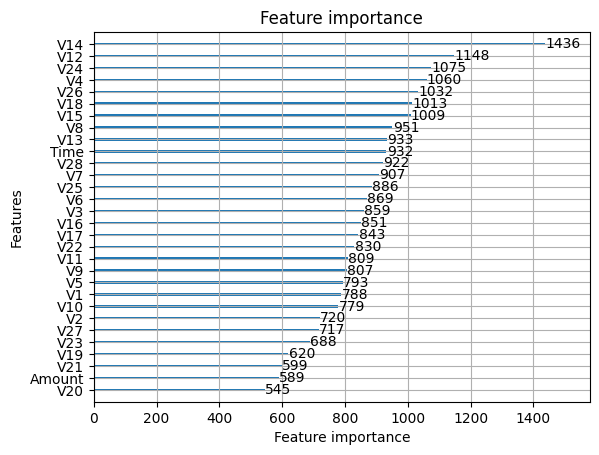

In [85]:
import pandas as pd
import matplotlib.pyplot as plt

plot_importance(gbm_baseline)
plt.show()

- 특성을 일부 가리고 모델에 학습 시켰을때, 14번째 특성을 기준으로 분할하면 가장 큰 손실 값 감소를 볼 수 있음

In [86]:
# 확률 예측: 훈련 데이터에 대해 예측 수행
y_pred_proba_train = gbm_baseline.predict(
    x_train_scaled,
    num_iteration=gbm_baseline.best_iteration
)

# 분류 예측 (임계값 0.5 사용)
threshold = 0.5
y_pred_train = (y_pred_proba_train >= threshold).astype(int)

# 성능 지표 계산
roc_auc_train = roc_auc_score(y_train_new, y_pred_proba_train)
precision_train = precision_score(y_train_new, y_pred_train)
recall_train = recall_score(y_train_new, y_pred_train)

print("\n--- 📈 LightGBM 훈련 (Train) 세트 성능 ---")
print(f"  - ROC AUC: {roc_auc_train:.4f} (이 수치는 높을수록 좋음)")
print(f"  - 정밀도 (Precision): {precision_train:.4f}")
print(f"  - 재현율 (Recall): {recall_train:.4f}")
print("-----------------------------------------")


--- 📈 LightGBM 훈련 (Train) 세트 성능 ---
  - ROC AUC: 1.0000 (이 수치는 높을수록 좋음)
  - 정밀도 (Precision): 0.9844
  - 재현율 (Recall): 1.0000
-----------------------------------------


In [87]:
# --- 검증 (Validation) 세트 성능 측정 ---
print("\n--- 📊 검증 (Validation) 세트 성능 측정 ---")
# 확률 예측: 검증 데이터에 대해 예측 수행
y_pred_proba_val = gbm_baseline.predict(
    x_val_scaled,
    num_iteration=gbm_baseline.best_iteration # 최적의 반복 횟수 사용
)

# 분류 예측 (임계값 0.5 사용)
y_pred_val = (y_pred_proba_val >= threshold).astype(int)

# 성능 지표 계산
roc_auc_val = roc_auc_score(y_validation, y_pred_proba_val)
precision_val = precision_score(y_validation, y_pred_val)
recall_val = recall_score(y_validation, y_pred_val)

print("\n--- 📝 LightGBM 검증 (Validation) 세트 성능 ---")
print(f"  - ROC AUC: {roc_auc_val:.4f}")
print(f"  - 정밀도 (Precision): {precision_val:.4f}")
print(f"  - 재현율 (Recall): {recall_val:.4f}")
print("---------------------------------------------")


--- 📊 검증 (Validation) 세트 성능 측정 ---

--- 📝 LightGBM 검증 (Validation) 세트 성능 ---
  - ROC AUC: 0.9778
  - 정밀도 (Precision): 0.8400
  - 재현율 (Recall): 0.7975
---------------------------------------------


In [88]:
# --- 테스트 (Test) 세트 성능 측정 ---
print("\n--- 🏁 최종 테스트 (Test) 세트 성능 측정 시작 ---")

# 확률 예측: 테스트 데이터에 대해 예측 수행
# LightGBM의 최적의 트리 개수(best_iteration)를 사용하여 예측합니다.
y_pred_proba_test = gbm_baseline.predict(
    x_test_scaled,
    num_iteration=gbm_baseline.best_iteration
)

# 분류 예측 (임계값 0.5 사용)
threshold = 0.5
y_pred_test = (y_pred_proba_test >= threshold).astype(int)

# 성능 지표 계산
roc_auc_test = roc_auc_score(y_test, y_pred_proba_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)

# 결과 출력
print("\n--- 🥇 LightGBM 최종 테스트 (Test) 세트 성능 ---")
print(f"  - ROC AUC: {roc_auc_test:.4f} (일반화 성능의 주요 지표)")
print(f"  - 정밀도 (Precision): {precision_test:.4f}")
print(f"  - 재현율 (Recall): {recall_test:.4f}")
print("--------------------------------------------------")


--- 🏁 최종 테스트 (Test) 세트 성능 측정 시작 ---

--- 🥇 LightGBM 최종 테스트 (Test) 세트 성능 ---
  - ROC AUC: 0.9736 (일반화 성능의 주요 지표)
  - 정밀도 (Precision): 0.8632
  - 재현율 (Recall): 0.8367
--------------------------------------------------


# 7. 추가 실험(특성 중요도가 낮은 특성을 제거하고 학습해보기) -Gemini 참조


In [89]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

importance = gbm_baseline.feature_importance(importance_type='split')
feature_names = gbm_baseline.feature_name()
feature_imp = pd.DataFrame({'Value': importance, 'Feature': feature_names})
feature_imp = feature_imp.sort_values(by="Value", ascending=False)
N_TO_DROP = 3
features_to_drop = feature_imp.tail(N_TO_DROP)['Feature'].values
print(f"🗑️ 제거할 특성 ({N_TO_DROP}개): {features_to_drop}")
cols = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount']
X_train_reduced = pd.DataFrame(x_train_scaled, columns=cols)
X_val_reduced = pd.DataFrame(x_val_scaled, columns=cols)
X_test_reduced = pd.DataFrame(x_test_scaled, columns=cols)
X_train_reduced = X_train_reduced.drop(columns=features_to_drop)
X_val_reduced = X_val_reduced.drop(columns=features_to_drop)
X_test_reduced = X_test_reduced.drop(columns=features_to_drop)
lgb_train = lgb.Dataset(X_train_reduced,y_train_new,feature_name = list(X_train_reduced.columns))
lgb_val = lgb.Dataset(X_val_reduced,y_validation,reference = lgb_train,feature_name = list(X_val_reduced.columns))


print(f"차원 축소 완료: {x_train_scaled.shape[1]} -> {X_train_reduced.shape[1]} features")

🗑️ 제거할 특성 (3개): ['V21' 'Amount' 'V20']
차원 축소 완료: 30 -> 27 features


# 7.1 학습 진행

In [90]:
import lightgbm as lgb
evals_result = {}
gbm_baseline = lgb.train(
    params,
    lgb_train,
    num_boost_round = params['n_estimators'],
    valid_sets=[lgb_train,lgb_val],
    valid_names=['train','validation'],
    callbacks=[
        lgb.record_evaluation(evals_result),
        lgb.early_stopping(100, verbose=False)]
)
print(f"✅ 베이스라인 모델 학습 완료. 최적의 트리 개수: {gbm_baseline.best_iteration}")

[LightGBM] [Info] Number of positive: 315, number of negative: 181961
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.047196 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6885
[LightGBM] [Info] Number of data points in the train set: 182276, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001728 -> initscore=-6.358975
[LightGBM] [Info] Start training from score -6.358975
✅ 베이스라인 모델 학습 완료. 최적의 트리 개수: 873


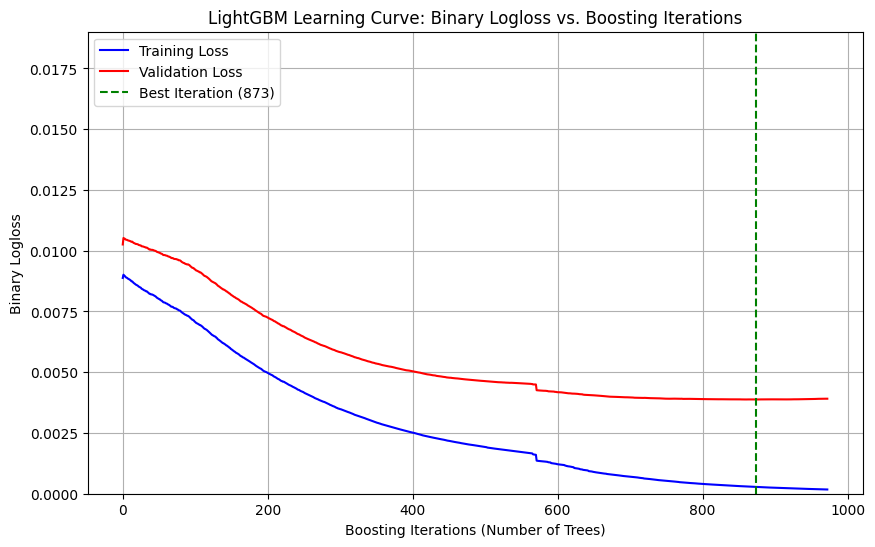

✅ 학습 곡선 그래프 시각화 완료.


In [91]:
import matplotlib.pyplot as plt
# --- 그래프 시각화 ---
metric_key = 'binary_logloss' # 사용자가 설정한 평가 지표 키

# 로그 손실 값 추출
train_loss = evals_result['train'][metric_key]
validation_loss = evals_result['validation'][metric_key]
iterations = range(len(train_loss))

plt.figure(figsize=(10, 6))

# 훈련 손실 곡선 (파란색)
plt.plot(iterations, train_loss, label='Training Loss', color='blue')

# 검증 손실 곡선 (빨간색)
plt.plot(iterations, validation_loss, label='Validation Loss', color='red')

# 조기 종료 지점 표시
best_iter = gbm_baseline.best_iteration
plt.axvline(best_iter, color='green', linestyle='--', label=f'Best Iteration ({best_iter})')

plt.title('LightGBM Learning Curve: Binary Logloss vs. Boosting Iterations')
plt.xlabel('Boosting Iterations (Number of Trees)')
plt.ylabel('Binary Logloss')
plt.legend()
plt.grid(True)
plt.ylim(0.0, max(train_loss) + 0.01) # y축 범위를 조정하여 낮은 값도 잘 보이도록 함
plt.show()

print("✅ 학습 곡선 그래프 시각화 완료.")

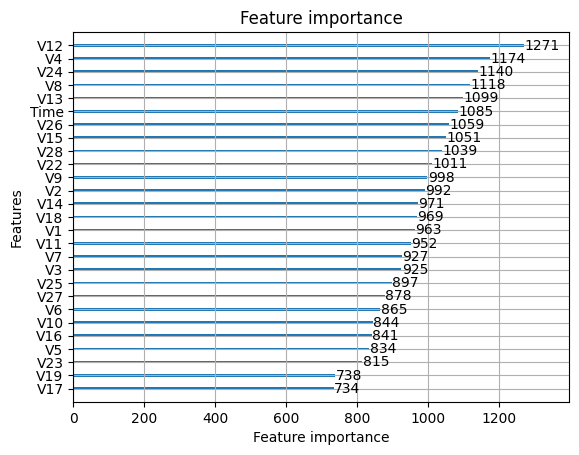

In [92]:
import pandas as pd
import matplotlib.pyplot as plt

plot_importance(gbm_baseline)
plt.show()

In [93]:
# 확률 예측: 훈련 데이터에 대해 예측 수행
y_pred_proba_train = gbm_baseline.predict(
    X_train_reduced,
    num_iteration=gbm_baseline.best_iteration
)

# 분류 예측 (임계값 0.5 사용)
threshold = 0.5
y_pred_train = (y_pred_proba_train >= threshold).astype(int)

# 성능 지표 계산
roc_auc_train = roc_auc_score(y_train_new, y_pred_proba_train)
precision_train = precision_score(y_train_new, y_pred_train)
recall_train = recall_score(y_train_new, y_pred_train)

print("\n--- 📈 LightGBM 훈련 (Train) 세트 성능 ---")
print(f"  - ROC AUC: {roc_auc_train:.4f} (이 수치는 높을수록 좋음)")
print(f"  - 정밀도 (Precision): {precision_train:.4f}")
print(f"  - 재현율 (Recall): {recall_train:.4f}")
print("-----------------------------------------")


--- 📈 LightGBM 훈련 (Train) 세트 성능 ---
  - ROC AUC: 1.0000 (이 수치는 높을수록 좋음)
  - 정밀도 (Precision): 0.9783
  - 재현율 (Recall): 1.0000
-----------------------------------------


In [94]:
# --- 검증 (Validation) 세트 성능 측정 ---
print("\n--- 📊 검증 (Validation) 세트 성능 측정 ---")
# 확률 예측: 검증 데이터에 대해 예측 수행
y_pred_proba_val = gbm_baseline.predict(
    X_val_reduced,
    num_iteration=gbm_baseline.best_iteration # 최적의 반복 횟수 사용
)

# 분류 예측 (임계값 0.5 사용)
y_pred_val = (y_pred_proba_val >= threshold).astype(int)

# 성능 지표 계산
roc_auc_val = roc_auc_score(y_validation, y_pred_proba_val)
precision_val = precision_score(y_validation, y_pred_val)
recall_val = recall_score(y_validation, y_pred_val)

print("\n--- 📝 LightGBM 검증 (Validation) 세트 성능 ---")
print(f"  - ROC AUC: {roc_auc_val:.4f}")
print(f"  - 정밀도 (Precision): {precision_val:.4f}")
print(f"  - 재현율 (Recall): {recall_val:.4f}")
print("---------------------------------------------")


--- 📊 검증 (Validation) 세트 성능 측정 ---

--- 📝 LightGBM 검증 (Validation) 세트 성능 ---
  - ROC AUC: 0.9660
  - 정밀도 (Precision): 0.8630
  - 재현율 (Recall): 0.7975
---------------------------------------------


In [95]:
# --- 테스트 (Test) 세트 성능 측정 ---
print("\n--- 🏁 최종 테스트 (Test) 세트 성능 측정 시작 ---")

# 확률 예측: 테스트 데이터에 대해 예측 수행
# LightGBM의 최적의 트리 개수(best_iteration)를 사용하여 예측합니다.
y_pred_proba_test = gbm_baseline.predict(
    X_test_reduced,
    num_iteration=gbm_baseline.best_iteration
)

# 분류 예측 (임계값 0.5 사용)
threshold = 0.5
y_pred_test = (y_pred_proba_test >= threshold).astype(int)

# 성능 지표 계산
roc_auc_test = roc_auc_score(y_test, y_pred_proba_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)

# 결과 출력
print("\n--- 🥇 LightGBM 최종 테스트 (Test) 세트 성능 ---")
print(f"  - ROC AUC: {roc_auc_test:.4f} (일반화 성능의 주요 지표)")
print(f"  - 정밀도 (Precision): {precision_test:.4f}")
print(f"  - 재현율 (Recall): {recall_test:.4f}")
print("--------------------------------------------------")


--- 🏁 최종 테스트 (Test) 세트 성능 측정 시작 ---

--- 🥇 LightGBM 최종 테스트 (Test) 세트 성능 ---
  - ROC AUC: 0.9775 (일반화 성능의 주요 지표)
  - 정밀도 (Precision): 0.8400
  - 재현율 (Recall): 0.8571
--------------------------------------------------


- 특성을 제거하기 전과 후 성능의 큰 차이가 없음.오히려 테스트 세트에 대한 재현율은 상승함
- 매니폴드 가설이 어느정도 맞음을 확인 할 수 있음.